######1. 라이브러리 호출

In [1]:
import gym
import math
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple  # 약간 튜플+딕셔너리 : 첫 번째 인자로 클래스 이름을, 두 번째 인자로는 필드 이름의 리스트나 튜플을 전달
from itertools import count # 무한 루프 사용
from PIL import Image  # 이미지 처리용

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T

env = gym.make('CartPole-v1').unwrapped  # cartpole이라는 강화 학습 환경 불러옴
plt.ion()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist

In [2]:
print(device)

cuda


#####2. 한글 깨짐 방지 in Colab

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 나눔폰트 활용
!apt-get -qq install fonts-nanum

# 폰트 적용
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font_name

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

Selecting previously unselected package fonts-nanum.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


##### 3. 리플레이 메모리

In [4]:
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward')) #상태 전이와 관련된 정보를 저장 : 현재상태('state', 'action')->다음 상태 및 보상('next_state', 'reward')

class ReplayMemory(object): #리플레이 메모리
    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = []
        self.position = 0

    def push(self, *args):
        if len(self.memory) < self.capacity:
            self.memory.append(None)
        self.memory[self.position] = Transition(*args)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size): #리플레이 메모리에 저장된 데이터 중 랜덤하게 반환 > 데이터의 상관관계 끊어서 학습효율 up
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)


##### 4. DQN 모델 네트워크

In [5]:
# CartPole 예제 : agent의 모든 행동이 예측 가능한 상황을 가정 but 현실적으로 불가능함 -> Q함수와 유사하도록
# 모델 학습의 목표 : 누적 보상이 최대
class DQN(nn.Module):
    def __init__(self, h, w, outputs):
        super(DQN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, stride=2)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=2)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=5, stride=2)
        self.bn3 = nn.BatchNorm2d(32)

        def conv2d_size_out(size, kernel_size=5, stride=2):
            return (size - (kernel_size - 1) - 1) // stride + 1

        convw = conv2d_size_out(conv2d_size_out(conv2d_size_out(w)))
        convh = conv2d_size_out(conv2d_size_out(conv2d_size_out(h)))
        linear_input_size = convw * convh * 32
        self.head = nn.Linear(linear_input_size, outputs)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        return self.head(x.view(x.size(0), -1)) #함수의 반환값 1차원으로 매핑

In [7]:
!pip install pyglet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 59.4 MB/s eta 0:00:00


#####5. 이미지 추출 및 처리

/usr/local/lib/python3.12/dist-packages/gym/core.py:43: DeprecationWarning: WARN: The argument mode in render method is deprecated; use render_mode during environment initialization instead.
See here for more information: https://www.gymlibrary.ml/content/api/
  deprecation(
/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning

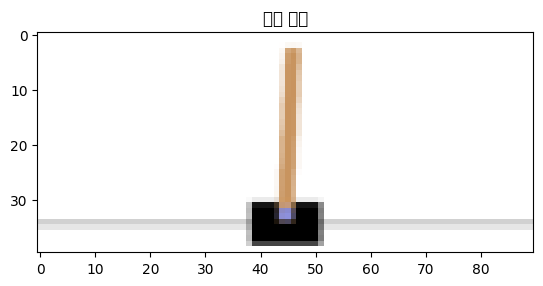

In [9]:
import pyglet

resize = T.Compose([T.ToPILImage(),
                  T.Resize(40, interpolation=Image.Resampling.BICUBIC),
                  T.ToTensor()]) # 이미지 크기 및 텐서 변환

def get_cart_location(screen_width):  # 카트 위치 정보 가져오기
    world_width = env.x_threshold * 2
    scale = screen_width / world_width
    return int(env.state[0] * scale + screen_width / 2.0) # 카트 중간(중앙) 위치

def get_screen(): #epsilon greedy 정책에 따라 action을 선택, 활용과 탐험
    screen = env.render(mode='rgb_array').transpose((2,0,1))
    _, screen_height, screen_width = screen.shape
    screen = screen[:, int(screen_height*0.4):int(screen_height*0.8)]
    view_width = int(screen_width * 0.6)
    cart_location = get_cart_location(screen_width)

    if cart_location < view_width //2 :
        # 카트는 출력 화면 아래쪽 중앙에 존재하므로 화면 위쪽과 아래쪽 제거
        slice_range = slice(view_width) #데이터의 형태를 (채널, 높이, 너비)로 바꾸기
    elif cart_location > (screen_width - view_width // 2):
        slice_range = slice(-view_width, None)
    else:
        slice_range = slice(cart_location - view_width // 2,
                            cart_location + view_width // 2)
    screen = screen[:, :, slice_range] # 카트가 화면 중앙에 위치하도록 가장자리 제거
    screen = np.ascontiguousarray(screen, dtype=np.float32) / 255
    screen = torch.from_numpy(screen) # 텐서로 변환
     # 출력 크기 조정 및 배치 차원 추가하여 데이터는 (배치, 채널, 높이, 너비) 형태 가짐
    return resize(screen).unsqueeze(0).to(device)


env.reset()  # 환경 초기화
plt.figure()
plt.imshow(get_screen().cpu().squeeze(0).permute(1,2,0).numpy(),
          interpolation='none')  # permute 함수 : transpose 함수처럼 차원 바꾸어 표현
plt.title('화면 예시')
plt.show()

##### 6. 모델 객체화 및 손실 함수 정의

In [10]:
BATCH_SIZE = 128
GAMMA = 0.999
EPS_START = 0.9 #epsilon 시작값
EPS_END = 0.05 #epsilon 최종값
EPS_DECAY = 200 #epsilon 감소 속도
TARGET_UPDATE = 10

init_screen = get_screen()
_, _, screen_height, screen_width = init_screen.shape
n_actions = env.action_space.n   # gym에서 행동(action)에 대한 횟수 가져옴.

policy_net = DQN(screen_height, screen_width, n_actions).to(device)
target_net = DQN(screen_height, screen_width, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict()) #모델 파라미터 값 불러오기
target_net.eval()

optimizer = optim.RMSprop(policy_net.parameters())
memory = ReplayMemory(10000) # 리플레이 메모리 설정

steps_done = 0

def select_action(state): #epsilon-greedy policy에 따라 행동을 선택하는 함수
    global steps_done
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * \
        math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    if sample > eps_threshold: # 탐험 시 가장 큰 Q 값 선택
        with torch.no_grad():
            return policy_net(state).max(1)[1].view(1, 1)

    else: # 활용시
        return torch.tensor([[random.randrange(n_actions)]], device=device, dtype=torch.long)

episode_durations = []

/usr/local/lib/python3.12/dist-packages/gym/core.py:43: DeprecationWarning: WARN: The argument mode in render method is deprecated; use render_mode during environment initialization instead.
See here for more information: https://www.gymlibrary.ml/content/api/
  deprecation(


##### 7. 모델에서 사용할 옵티마이저 정의

In [11]:
def optimize_model():
    if len(memory) < BATCH_SIZE:
        return

    transitions = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions)) #zip은 transpose 역할
    #게임 상태를 계산하기 위한 코드
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                            batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                       if s is not None]) # torch.cat 이용하여 s값들을 이어 붙임

    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    state_action_values = policy_net(state_batch).gather(1, action_batch)  # Q(st, at) 계산
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    next_state_values[non_final_mask] = target_net(non_final_next_states).max(1)[0].detach()

    expected_state_action_values = (next_state_values * GAMMA) + reward_batch  # V(s{t+1}) 계산
    # loss : L1 손실과 L2 손실 결합한 함수
    loss = F.smooth_l1_loss(state_action_values, expected_state_action_values.unsqueeze(1))
    optimizer.zero_grad()
    loss.backward()

    for param in policy_net.parameters():
        param.grad.data.clamp_(-1, 1)

    optimizer.step()

##### 8. 모델 학습

In [13]:
num_episodes = 50

for i_episode in range(num_episodes):
    env.reset()   # 환경과 상태 초기화
    last_screen = get_screen()
    current_screen = get_screen()
    state = current_screen - last_screen

    for t in count():
        action = select_action(state)  # 행동 선택 및 실행
        step_output = env.step(action.item())
        reward = step_output[1]  # reward is the 2nd value in the returned tuple/list
        done = step_output[2]
        # 선택된 행동(action)을 환경으로
        reward = torch.tensor([reward], device=device)

        last_screen = current_screen
        current_screen = get_screen()

        if not done:  # observe
            next_state = current_screen - last_screen
        else:
            next_state = None

        memory.push(state, action, next_state, reward)  # state transition 메모리에 저장
        state = next_state  # 다음 상태로 이동

        optimize_model()  # 타깃(큐) 네트워크에 대해 최적화 진행
        if done:
            episode_durations.append(t + 1)
            break

    if i_episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())
        # 큐 네트워크의 모든 가중치와 바이어스를 복사하여 타깃 네크워트 업데이트

print('종료')
#env.render()  # 화면 출력
#env.close()  # 화면 종료
plt.show()

종료
